# Permutation Feature Importance (PFI)
### Diabetes dataset — Random Forest Regressor

This notebook implements Permutation Feature Importance (PFI) to explain
a Random Forest model, following the standard PFI methodology:
train the model, get baseline performance, shuffle each feature, and
measure the resulting drop in performance.

## 1. Imports

In [1]:
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse, r2_score
from sklearn.datasets import load_diabetes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the data

In [2]:
data = load_diabetes()
x = data.data
y = data.target
print(x.shape)
print(y.shape)

(442, 10)
(442,)


## 3. Get feature names and build a DataFrame

In [3]:
columns = data.feature_names.copy()
print(columns)

df = pd.DataFrame(x, columns=columns)
df['target'] = y
df.head()

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 4. Correlation heatmap
Sanity check on relationships between features and the target before modeling.

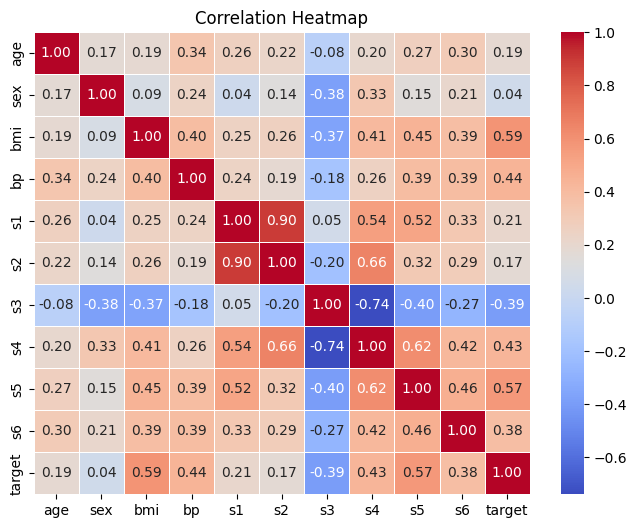

In [4]:
corr_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## 5. Train/test split

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.4, random_state=42
)

## 6. Train the Random Forest model (Step 1 of PFI)
This is the "black box" model we want to explain.

In [6]:
model = RFR(n_estimators=100, random_state=42)
model = model.fit(x_train, y_train)

## 7. Built-in Random Forest feature importances
(For comparison later against PFI's results.)

In [7]:
for col, val in zip(columns, model.feature_importances_):
    print("{}: {:.2f}, ".format(col, val), end="")

age: 0.07, sex: 0.01, bmi: 0.39, bp: 0.11, s1: 0.05, s2: 0.06, s3: 0.05, s4: 0.02, s5: 0.18, s6: 0.06, 

## 8. Predictions vs. actuals (spot check)

In [8]:
predictions = model.predict(x_test)
print("Predictions:", " ".join(f"{v:.0f}" for v in predictions[:10]))
print("Actuals:    ", " ".join(f"{v:.0f}" for v in y_test[:10]))

Predictions: 143 184 156 248 118 116 237 202 146 162
Actuals:     219 70 202 230 111 84 242 272 94 96


## 9. Get the Baseline Performance (Step 2 of PFI)
RMSE and R² measured on the untouched test set — this is the benchmark
we compare against after permuting each feature.

In [9]:
rms = np.sqrt(mse(y_test, predictions))
print("RMSE: {:.2f}".format(rms))
r2 = model.score(x_test, y_test)
print("R2: {:.2f}".format(r2))

RMSE: 54.69
R2: 0.49


## 10. Apply Permutation Feature Importance (Steps 3-5 of PFI)
For each feature: shuffle its values in the test set, re-run the model,
and measure how much RMSE gets worse. `n_repeats=10` means this is
repeated 10 times per feature and averaged, to reduce randomness in the result.

In [10]:
result = permutation_importance(
    model, x_test, y_test, n_repeats=10,
    random_state=42, scoring='neg_root_mean_squared_error'
)

for i in range(len(result.importances_mean)):
    print(f"Feature {data.feature_names[i]}: {result.importances_mean[i]:.3f} +/- {result.importances_std[i]:.3f}")

Feature age: 0.360 +/- 0.513
Feature sex: 0.325 +/- 0.320
Feature bmi: 13.754 +/- 1.237
Feature bp: 2.453 +/- 0.721
Feature s1: -0.366 +/- 0.277
Feature s2: -0.025 +/- 0.374
Feature s3: 1.260 +/- 0.535
Feature s4: 0.202 +/- 0.051
Feature s5: 9.969 +/- 0.647
Feature s6: 1.404 +/- 0.438


## 11. Build a summary table

In [11]:
dfSummary = pd.DataFrame({
    'Variable': columns,
    'importance': result.importances_mean,
    'coeff_lb': result.importances_mean - result.importances_std,
    'coeff_ub': result.importances_mean + result.importances_std
})
dfSummary.head(10)

,Variable,importance,coeff_lb,coeff_ub
0,age,0.360015,-0.153319,0.873349
1,sex,0.325104,0.004889,0.645319
2,bmi,13.753906,12.516830,14.990983
3,bp,2.453359,1.732593,3.174124
4,s1,-0.365711,-0.642909,-0.088514
5,s2,-0.024554,-0.398930,0.349822
6,s3,1.260328,0.725820,1.794836
7,s4,0.202412,0.151232,0.253592
8,s5,9.969055,9.321640,10.616471
9,s6,1.403700,0.965332,1.842069


## 12. Sort by importance
Sorted ascending here so the horizontal bar chart reads with the most
important feature at the top.

In [12]:
dfSorted = dfSummary.sort_values(by="importance", ascending=True)
dfSorted

,Variable,importance,coeff_lb,coeff_ub
4,s1,-0.365711,-0.642909,-0.088514
5,s2,-0.024554,-0.398930,0.349822
7,s4,0.202412,0.151232,0.253592
1,sex,0.325104,0.004889,0.645319
0,age,0.360015,-0.153319,0.873349
6,s3,1.260328,0.725820,1.794836
9,s6,1.403700,0.965332,1.842069
3,bp,2.453359,1.732593,3.174124
8,s5,9.969055,9.321640,10.616471
2,bmi,13.753906,12.516830,14.990983


## 13. Plot: Permutation Feature Importance
This visualizes the permutation importance results. `bmi` should come out
as the most important feature, matching the RMSE-based importance.

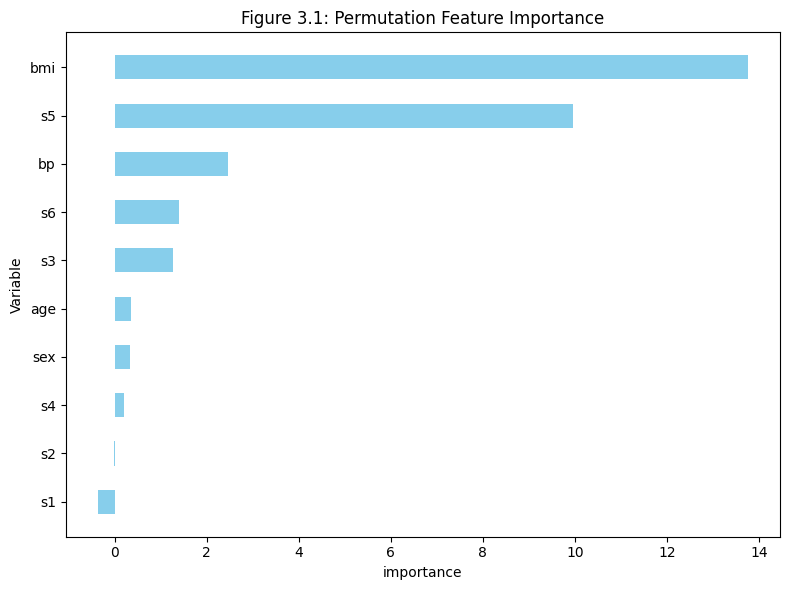

In [13]:
plt.figure(figsize=(8, 6))
plt.barh(dfSorted['Variable'], dfSorted['importance'], color='skyblue', height=0.5)
plt.xlabel('importance')
plt.ylabel('Variable')
plt.title('Figure 3.1: Permutation Feature Importance')
plt.tight_layout()
plt.show()

## 14. Reading the results

- **Baseline RMSE / R²** — the model's performance before any permutation; this is
  the benchmark every feature's importance is measured against.
- **Positive importance** — shuffling that feature made RMSE worse, meaning the model
  actually relies on it (e.g. `bmi`, `s5`).
- **Near-zero or negative importance** — shuffling that feature barely changed RMSE,
  or even slightly improved it (e.g. `s1`, `s2`), meaning the model doesn't meaningfully
  depend on the real values of that feature.
- The **built-in Random Forest importances** (Step 7) and the **PFI importances** (Step 10)
  can be compared — they don't have to agree perfectly, since they measure importance
  in different ways (impurity reduction vs. actual performance impact on unseen data).